# CS171 Analysis & Visualization Notebook - Ryan Tran and Andres Aclan
### Predicting Diabetes Risk Using Diagnostic Health Features

This notebook focuses on **interpreting and visualizing the performance** of my trained Random Forest model on the Pima Indians Diabetes dataset.  

Unlike the **data preprocessing** and **model training** notebook, this notebook is dedicated to:  
- showing the **model in action**,  
- analyzing predictions,  
- explaining what the results mean, and  
- relating the findings to our core research question:

> **Can lifestyle, health, and demographic features be used to predict diabetes risk?**

## Pima Indians Diabetes Dataset
**Author:** Ryan Tran

### Load Dependencies, Data, and Model

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
)

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (8,5)

# Load processed data
X_test = pd.read_csv("ryan_data/processed/X_test_clean.csv")
y_test = pd.read_csv("ryan_data/processed/y_test_clean.csv").squeeze()

# Load trained model
model = joblib.load("ryan_data/models/best_random_forest.pkl")

print("Loaded test data + trained Random Forest model.")


Loaded test data + trained Random Forest model.


### Generate predictions

In [26]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]


In [27]:
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC AUC": roc_auc_score(y_test, y_proba)
}

pd.DataFrame(metrics, index=["Random Forest"])


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Random Forest,0.753247,0.621212,0.759259,0.683333,0.816296


### Model Evaluation

Random Forest classifier on the cleaned test set:

- **Accuracy ~0.75**
- **Precision ~0.62**
- **Recall ~0.76**
- **F1 Score ~0.68**
- **ROC AUC ~0.82**

These numbers are not amazing, but they fall into a kind of “middle ground”:
The model is clearly learning from the features, but I cannot confidently call it an extra reliable diagnostic tool.

Overall, these metrics serve as a moderately useful risk model built from basic health metrics.  
It’s good enough to show that the features contain meaningful information about diabetes risk, but could use some work before implemented fully in a clinical workflow.

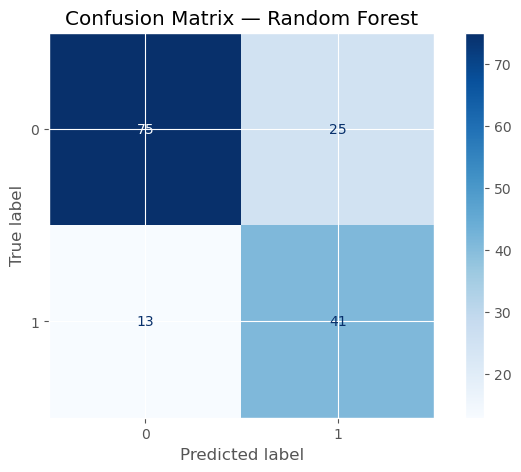

In [28]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Confusion Matrix — Random Forest")
plt.show()


### Confusion Matrix Interpretation

The confusion matrix shows:

- **True Negatives (TN):** Non-diabetic patients correctly classified as 0  
- **True Positives (TP):** Diabetic patients correctly classified as 1  
- **False Positives (FP):** Non-diabetic patients incorrectly labeled as diabetic  
- **False Negatives (FN):** Diabetic patients incorrectly labeled as non-diabetic  

In a medical context, these two types of mistakes are not equally bad:

- **False Positives (FP)**  
  - The model says “you might have diabetes” when you don’t.  
  - Consequences: extra follow-up, more testing, maybe anxiety or cost.  
  - This is undesirable and inefficient, but often fine in a scenario where patients do further testing.

- **False Negatives (FN)**  
  - The model says “you’re fine” when you actually have diabetes.  
  - Consequences: delayed diagnosis, missed chance of earlier treatment
  - In clinical settings, **false negatives are more dangerous** than false positives.

From a screening perspective, this model is **leaning more toward detecting diabetics (higher recall) at the cost of some false alarms (lower precision)**.  

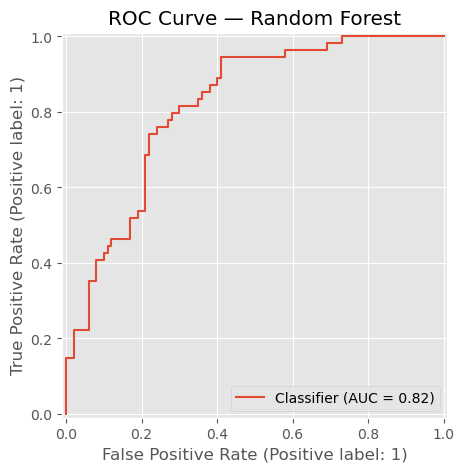

In [29]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve — Random Forest")
plt.show()


### ROC Curve Interpretation
The ROC curve shows the trade-off between:

- **True Positive Rate (Recall)** — how many diabetics we correctly identify  
- **False Positive Rate** — how many healthy people we incorrectly label as diabetic


The ROC AUC score of **0.82** indicates that:
The model is better than random guessing by a fair margin (random = 0.5).  
There is a decent chance of assigning a higher risk score to the true diabetic patient.

However, **it is not close to perfect separation (AUC = 1.0)**

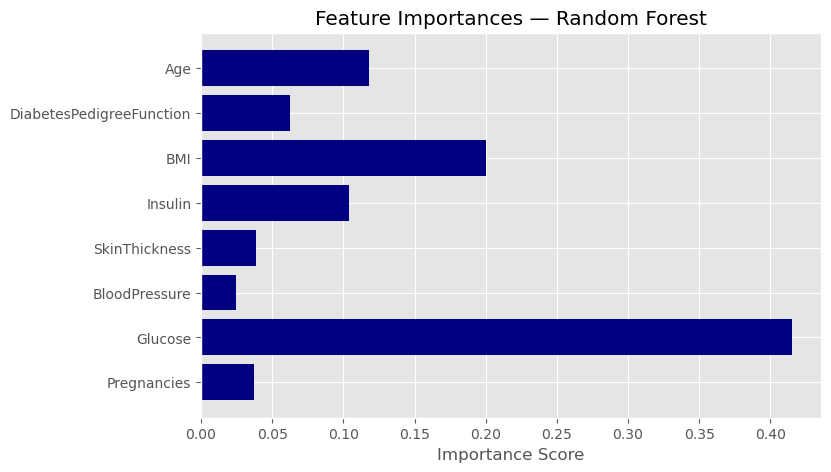

In [30]:
importances = model.feature_importances_
features = X_test.columns

plt.figure(figsize=(8,5))
plt.barh(features, importances, color="navy")
plt.title("Feature Importances — Random Forest")
plt.xlabel("Importance Score")
plt.show()


### Feature Importance

According to the figure, we notice that the most influential predictors for diabetes include:

1. **Glucose level**: Strongest signal (consistent with medical literature)  
2. **BMI**: Known risk factor for Type II diabetes  
3. **Age**: Strong demographic predictor  
4. **Diabetes Pedigree Function**: Genetic risk component  
5. **Insulin**: Despite missing values, still informative after median imputation  
6. **Pregnancies**: Women with higher pregnancies have higher risk of [gestational diabetes](https://pmc.ncbi.nlm.nih.gov/articles/PMC7153959/)  

The features seem to align with  clinical knowledge!


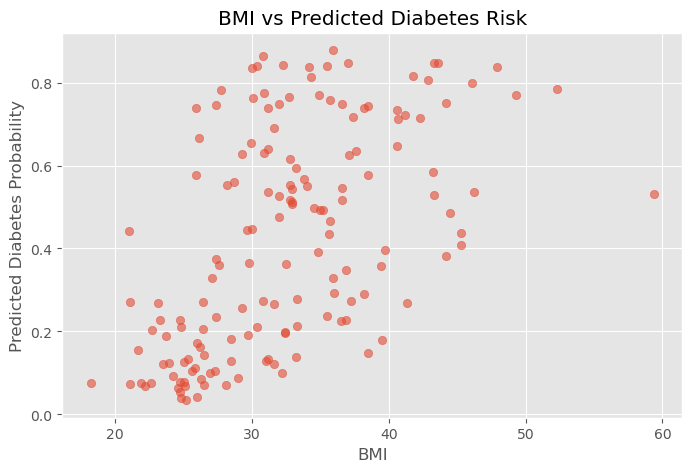

In [31]:
plt.scatter(X_test["BMI"], y_proba, alpha=0.6)
plt.xlabel("BMI")
plt.ylabel("Predicted Diabetes Probability")
plt.title("BMI vs Predicted Diabetes Risk")
plt.show()


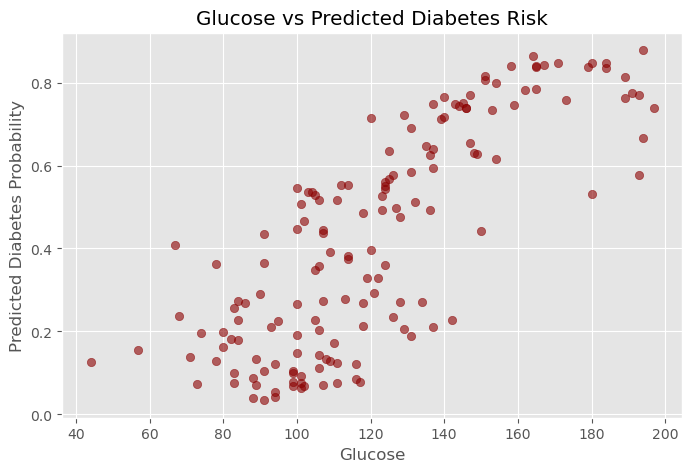

In [32]:
plt.scatter(X_test["Glucose"], y_proba, alpha=0.6, color="darkred")
plt.xlabel("Glucose")
plt.ylabel("Predicted Diabetes Probability")
plt.title("Glucose vs Predicted Diabetes Risk")
plt.show()


### Model Behavior

These scatterplots show how the model’s predicted probability increases with:

- **higher glucose**
- **higher BMI**
- **older age**

The trends follow medically correct patterns:
- High glucose means consistently high predicted diabetes risk  
- Low BMI is a lower predicted risk  
- High BMI is wider spread but generally higher risk  

This confirms the model is learning reasonable relationships.


# Summary and Key Points

### Moderate Metrics?

These scores aren't particularly amazing, so that leads to asking:
What is holding the model back?

Several factors likely contribute:

1. **Limited Feature Set**  
   - The Pima dataset includes only 8 simple features
   - Important clinical information is missing: duration of symptoms, family history in detail, medication, diet, activity level, and advanced lab markers.

2. **Noise and Missing Values**  
   - Some features (e.g., insulin and skin thickness) have many missing or zero values that we had to impute.  
   - If the original measurements are noisy or inconsistent, the model will reflect that.

3. **Small Dataset Size (768 rows)**  
   - Given this problem, more data would be ideal.  
   - Our size limits how well the model can learn rare edge cases. With more data, we can generalize better to new patients.

- The model is **better than chance and clearly learning real patterns**,  
- but it is **not strong enough** to act as a concrete clinical tool

### Revisiting the Research Question

> **Can lifestyle, health, and demographic features be used to predict diabetes risk?**

Based on my model and analysis, a careful answer is:

- These features do carry noteworthy information about diabetes risk.
  The model’s ROC AUC (0.82) and recall (0.76) show (given only these basic measurements) we can definitely do better than "chance" at identifying high-risk individuals.

- But these features alone are not sufficient for high-accuracy, low-error prediction. 
  The moderate precision (~0.62) and the presence of both false positives and false negatives indicate that *a fraction of predictions will be wrong*.

Based off my model and dataset, I would say:

> **Yes, lifestyle/health/demographic features are useful for *screening*, but they are not enough on their own to reliably diagnose diabetes. However, with even more reliable data, the use of machine learning can powerfully assist the process in medical decision-making.**  

A model like this could be used to:
- flag patients  
- prioritize follow-up for those with high predicted risk  
- but of course still emphasizes lab tests and clinical judgment.

## BRFSS 2015 Dataset
**Author:** Andres Aclan

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

In [34]:
df = pd.read_csv('andres_data/outputs/test_predictions.csv')
y_test_pred = df['y_pred']
y_test_prob = df['y_prob']
y_test = df['y_true']

print("\nTest set results:")
print(classification_report(y_test, y_test_pred, digits=4))
print("Confusion matrix (test):")
print(confusion_matrix(y_test, y_test_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_test_prob))


Test set results:
              precision    recall  f1-score   support

           0     0.9508    0.7323    0.8274     42741
           1     0.3226    0.7707    0.4548      7069

    accuracy                         0.7378     49810
   macro avg     0.6367    0.7515    0.6411     49810
weighted avg     0.8616    0.7378    0.7745     49810

Confusion matrix (test):
[[31300 11441]
 [ 1621  5448]]
Test ROC AUC: 0.8288006993033263


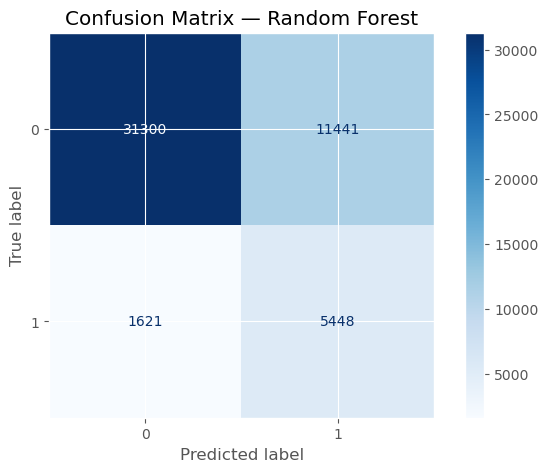

In [35]:
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, cmap="Blues")
plt.title("Confusion Matrix — Random Forest")
plt.show()

- The model shows strong performance on the majority class (0): high precision (0.9508) means nearly all "not diabetic" predictions are correct, and recall (0.7323) indicates it still finds most non-diabetics but mislabels some as diabetic.  
- For the diabetic class (1), recall is reasonably high (0.7707) so the model detects about 77% of actual diabetics, but precision is low (0.3225) meaning most predicted diabetics are false positives.  
- This pattern indicates the model prioritizes sensitivity to positive cases at the cost of flagging many false positives. For clinical screening, prioritizing recall is usually appropriate because missing a diabetic patient (false negative) has greater health risk than a false alarm; follow-up testing can rule out false positives.  

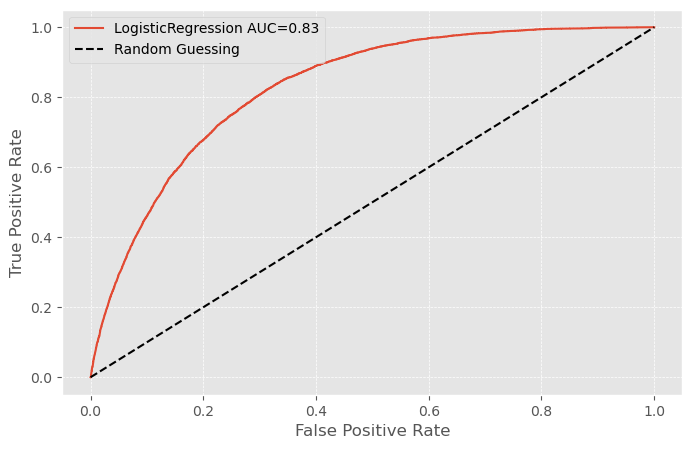

In [36]:
pipe = joblib.load('andres_data/models/logreg_pipe.joblib')
probabilities = y_test_prob
    
# compute the fpr, tpr using the roc_curve function
fpr, tpr, _ = roc_curve(y_test, probabilities, pos_label=1) 

# compute the auc score
auc = roc_auc_score(y_test, probabilities) 

# plot the curve and label with the model name
plt.plot(fpr, tpr, label='LogisticRegression'+' AUC='+'{:.2f}'.format(auc)) 

# add a random guessing line
plt.plot([0,1],[0,1],'k--', label='Random Guessing')

# format the axes
plt.grid(linestyle='--',linewidth=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

Our model is better than random guessing which is a good sign. For better results we would want to see the curve push toward the top left hand corner of the plot to maximize AUC.

### Model performance — summary

- **Mean misclassification loss:** ~0.264 (26.4%) (as seen in model notebook) 
- **Mean ROC AUC:** ~0.827 (fold AUCs averaged), test AUC ≈ 0.829

Interpretation:
- The model misclassifies roughly 1 in 4 samples, so there is room to reduce errors.
- AUC indicates good discrimination overall, but class-level performance (precision/recall) shows a trade‑off between sensitivity and false positives.

For real world use of this classification model, its best to use predict_proba due to the nature of disease. False positives are not good but so are false negatives. So using probability is much more well aligned with practical application. This model should only be used as data to advise a medical professional.

### Subgroups
Evaluating subgroup performance can identify disparities in metrics (e.g., precision, recall, AUC) across demographic or clinical slices so strong overall performance doesn't mask poor outcomes for vulnerable groups. Understanding this is useful to reduce bias and improve safety in clinical screening. And may reveal certain subgroups that can be predicted with better recall as we will see.

/var/folders/fk/n014_x4s1cd6k_v9hzzf1c780000gn/T/ipykernel_92470/916163820.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  report = df.groupby(bins).apply(lambda g: pd.Series({


,precision,recall,count
BMI,,,
"(11.999, 24.0]",0.204483,0.546455,14282.0
"(24.0, 27.0]",0.260348,0.661316,12347.0
"(27.0, 31.0]",0.305234,0.742954,11401.0
"(31.0, 98.0]",0.395983,0.884865,11780.0


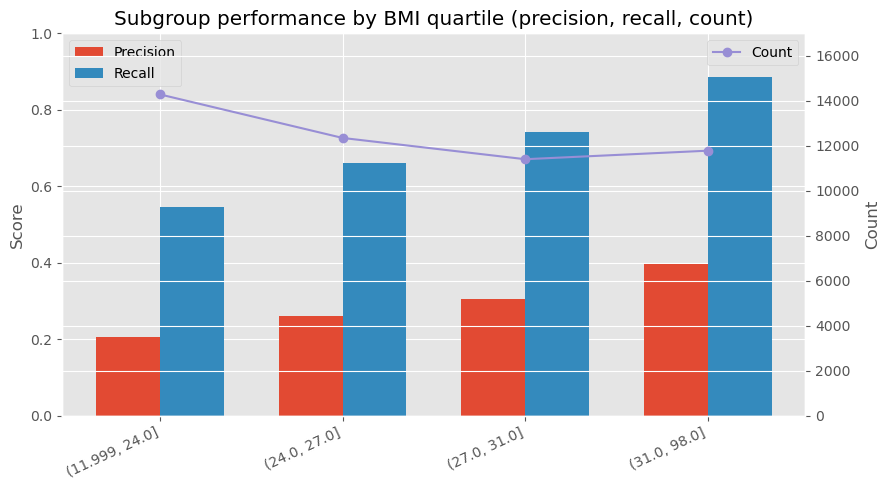

In [37]:
# Subgroup performance example (by BMI)
bins = pd.qcut(df['BMI'], q=4, duplicates='drop')
report = df.groupby(bins).apply(lambda g: pd.Series({
    'precision': precision_score(g['y_true'], g['y_pred'], zero_division=0),
    'recall': recall_score(g['y_true'], g['y_pred'], zero_division=0),
    'count': len(g)
}))
display(report)

report_df = report.copy()
precision = report_df['precision'].to_numpy()
recall = report_df['recall'].to_numpy()
counts = report_df['count'].to_numpy()
labels = [str(interval) for interval in report_df.index]  # readable x labels

x = np.arange(len(labels))
width = 0.35

fig, ax1 = plt.subplots(figsize=(9,5))
ax1.bar(x - width/2, precision, width, label='Precision', color='C0')
ax1.bar(x + width/2, recall, width, label='Recall', color='C1')
ax1.set_ylabel('Score')
ax1.set_ylim(0, 1.0)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=25, ha='right')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(x, counts, color='C2', marker='o', linestyle='-', label='Count')
ax2.set_ylim(0, 17000)
ax2.set_ylabel('Count')
ax2.legend(loc='upper right')

plt.title('Subgroup performance by BMI quartile (precision, recall, count)')
plt.tight_layout()
plt.show()

Recall rises with BMI and reaches about 88% in the >31 BMI subgroup, approaching 90%. This suggests the model detects diabetics more reliably among higher‑BMI individuals, likely due to BMI being a strong signal. However, precision remains much lower but still improving, so the higher recall comes with more false positives and warrants cautious interpretation or follow‑up testing. It is important to mention that the counts do vary across groups.

### Revisiting the Research Question

> **Can lifestyle, health, and demographic features be used to predict diabetes risk?**

Short answer: Yes—for screening, not diagnosis.

- The BRFSS logistic regression (our second model) shows meaningful discrimination (ROC AUC ≈ 0.83) and detects most diabetics (recall ≈ 77%) while producing many false positives (precision for diabetics ≈ 32%). Non‑diabetic predictions are very precise (≈ 95%).
- Misclassification loss is still substantial (~26%), so many individual predictions are still wrong.
- Practical implication: these features are useful to flag high‑risk individuals and prioritize follow‑up/testing, but they cannot replace lab tests or clinician judgment. Prefer predict_proba thresholds for triage decisions rather than hard class labels.